In [1]:
# ============================================================
# CELL 0: Import Library
# ============================================================
import os, time, warnings, pickle, json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from skimage.color import rgb2gray, rgb2lab
from skimage.filters import gabor_kernel
from scipy.ndimage import convolve
from scipy.stats import skew

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
print('Library imported.')

Library imported.


In [2]:
# ============================================================
# CELL 1: Config & Dataset Scan
# ============================================================
DATASET_ROOT = Path('/kaggle/input/datasets/shijo96john/facial-skin-acne-pigmentation-pores-wrinkles/dataset')
OUTPUT_DIR   = Path('/kaggle/working')
VALID_EXT    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}
IMG_SIZE     = (128, 128)
RANDOM_STATE = 42
TEST_SIZE    = 0.2
MIN_SAMPLES  = 200

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATASET_ROOT}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_DIRS  = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
CLASS_NAMES = [d.name for d in CLASS_DIRS]
NUM_CLASSES = len(CLASS_NAMES)

print(f'Config: {NUM_CLASSES} kelas')
print(f'   {"Kelas":<45} {"N":>6}  Status')
print('   ' + '-'*62)
class_counts = {}
for i, c in enumerate(CLASS_NAMES):
    n = len([f for f in CLASS_DIRS[i].iterdir()
              if f.suffix.lower() in VALID_EXT])
    class_counts[c] = n
    flag = '!! PRIORITAS' if n < MIN_SAMPLES else 'OK'
    print(f'   [{i}] {c:<45} ({n:>4} gambar) {flag}')

print()
low_classes = [k for k, v in class_counts.items() if v < MIN_SAMPLES]
if low_classes:
    print(f'Kelas dengan sampel < {MIN_SAMPLES}: {low_classes}')
else:
    print('Semua kelas memiliki sampel cukup (>= 200)')

Config: 8 kelas
   Kelas                                              N  Status
   --------------------------------------------------------------
   [0] Redness                                       ( 600 gambar) OK
   [1] dark spots                                    ( 619 gambar) OK
   [2] inflammatory acne                             ( 603 gambar) OK
   [3] non inflammatory acne black heads             ( 312 gambar) OK
   [4] non inflammatory acne white heads             ( 300 gambar) OK
   [5] pigmentation                                  ( 599 gambar) OK
   [6] pores                                         ( 600 gambar) OK
   [7] wrinkles                                      ( 600 gambar) OK

Semua kelas memiliki sampel cukup (>= 200)


In [3]:
# ============================================================
# CELL 2: Haar Cascade ROI (OpenCV)
# ============================================================
_FACE_CASCADE = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def crop_face_roi(img_rgb_uint8: np.ndarray) -> np.ndarray:
    """
    Deteksi wajah dengan OpenCV Haar Cascade.
    Jika wajah terdeteksi: crop + padding 10%.
    Jika tidak terdeteksi (foto close-up kulit): return gambar asli.
    Fallback aman — tidak ada gambar yang di-skip.
    """
    gray  = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2GRAY)
    faces = _FACE_CASCADE.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=4, minSize=(40, 40)
    )
    if len(faces) == 0:
        return img_rgb_uint8

    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    pad = int(0.10 * min(w, h))
    H, W = img_rgb_uint8.shape[:2]
    x1 = max(0, x - pad);  y1 = max(0, y - pad)
    x2 = min(W, x + w + pad); y2 = min(H, y + h + pad)
    return img_rgb_uint8[y1:y2, x1:x2]

print('Haar Cascade (OpenCV) initialized.')

Haar Cascade (OpenCV) initialized.


In [4]:
# ============================================================
# CELL 3: Preprocessing
# ============================================================

def load_and_preprocess(filepath: Path, img_size: tuple):
    """
    Load gambar → Haar Cascade ROI (fallback aman) → resize → normalize.
    """
    try:
        img     = Image.open(filepath).convert('RGB')
        img_np  = np.array(img, dtype=np.uint8)
        img_np  = crop_face_roi(img_np)
        img_pil = Image.fromarray(img_np).resize(img_size, Image.LANCZOS)
        return np.array(img_pil, dtype=np.float32) / 255.0
    except Exception:
        return None


def augment_image(img_arr: np.ndarray) -> list:
    """
    3 augmentasi ringan untuk kelas minoritas:
    flip horizontal, brightness +20%, brightness -20%.
    """
    pil  = Image.fromarray((img_arr * 255).astype(np.uint8))
    augs = []
    augs.append(np.array(pil.transpose(Image.FLIP_LEFT_RIGHT),
                          dtype=np.float32) / 255.0)
    augs.append(np.clip(
        np.array(ImageEnhance.Brightness(pil).enhance(1.2),
                  dtype=np.float32) / 255.0, 0, 1))
    augs.append(np.clip(
        np.array(ImageEnhance.Brightness(pil).enhance(0.8),
                  dtype=np.float32) / 255.0, 0, 1))
    return augs

In [5]:
# ============================================================
# CELL 4: Load Dataset
# ============================================================
print('Loading gambar (Haar Cascade ROI + fallback aman)...')
images_rgb_orig, labels_raw_orig = [], []
skipped = 0

for cls_dir in CLASS_DIRS:
    cls_name = cls_dir.name
    files    = sorted([f for f in cls_dir.iterdir()
                        if f.suffix.lower() in VALID_EXT])
    for fp in tqdm(files, desc=f'  {cls_name[:30]:<30}', leave=False):
        arr = load_and_preprocess(fp, IMG_SIZE)
        if arr is not None:
            images_rgb_orig.append(arr)
            labels_raw_orig.append(cls_name)
        else:
            skipped += 1

images_rgb_orig = np.array(images_rgb_orig, dtype=np.float32)
labels_raw_orig = np.array(labels_raw_orig)
print(f'Original: {len(images_rgb_orig)} gambar (skip={skipped})')

Loading gambar (Haar Cascade ROI + fallback aman)...


  Redness                       :   0%|          | 0/600 [00:00<?, ?it/s]

  dark spots                    :   0%|          | 0/619 [00:00<?, ?it/s]

  inflammatory acne             :   0%|          | 0/603 [00:00<?, ?it/s]

  non inflammatory acne black he:   0%|          | 0/312 [00:00<?, ?it/s]

  non inflammatory acne white he:   0%|          | 0/300 [00:00<?, ?it/s]

  pigmentation                  :   0%|          | 0/599 [00:00<?, ?it/s]

  pores                         :   0%|          | 0/600 [00:00<?, ?it/s]

  wrinkles                      :   0%|          | 0/600 [00:00<?, ?it/s]

Original: 4233 gambar (skip=0)


In [6]:
# ============================================================
# CELL 5: Feature Extraction
# Ekstrak SEMUA fitur dari gambar original dulu,
# BARU split + augmentasi di feature space.
# Ini fix root cause leakage: sebelumnya augmentasi di
# image space → fitur augmented masuk PCA fit → leakage.
# ============================================================

# HOG
def extract_hog(img_gray: np.ndarray) -> np.ndarray:
    return hog(img_gray, orientations=9, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), block_norm='L2-Hys',
               feature_vector=True)

# LBP multi-scale
def extract_lbp(img_gray: np.ndarray) -> np.ndarray:
    feats = []
    for R in [1, 2, 3]:
        P   = 8 * R
        lbp = local_binary_pattern(img_gray, P=P, R=R, method='uniform')
        n   = P + 2
        counts, _ = np.histogram(lbp.ravel(), bins=n, range=(0, n))
        feats.append((counts / (counts.sum() + 1e-8)).astype(np.float32))
    return np.concatenate(feats)

# Color Moments RGB + HSV + LAB
def extract_color_moments(img_rgb: np.ndarray) -> np.ndarray:
    feats = []
    for ch in range(3):
        c = img_rgb[:, :, ch].ravel()
        s = float(skew(c))
        feats += [float(c.mean()), float(c.std()),
                  float(np.clip((s + 3) / 6, 0, 1))]

    img_u8  = (img_rgb * 255).astype(np.uint8)
    img_hsv = np.array(Image.fromarray(img_u8).convert('HSV'),
                        dtype=np.float32) / 255.0
    for ch in range(3):
        c = img_hsv[:, :, ch].ravel()
        s = float(skew(c))
        feats += [float(c.mean()), float(c.std()),
                  float(np.clip((s + 3) / 6, 0, 1))]

    img_lab = rgb2lab(img_rgb)
    for ch, (lo, hi) in enumerate([(0, 100), (-128, 127), (-128, 127)]):
        c_raw = img_lab[:, :, ch].ravel()
        c     = np.clip((c_raw - lo) / (hi - lo + 1e-8), 0, 1)
        s     = float(skew(c_raw))
        feats += [float(c.mean()), float(c.std()),
                  float(np.clip((s + 3) / 6, 0, 1))]
    return np.array(feats, dtype=np.float32)

# Color Histogram 16 bin
def extract_color_histogram(img_rgb: np.ndarray) -> np.ndarray:
    feats = []
    BINS  = 16
    for ch in range(3):
        counts, _ = np.histogram(img_rgb[:, :, ch].ravel(),
                                  bins=BINS, range=(0.0, 1.0))
        feats.append((counts / (counts.sum() + 1e-8)).astype(np.float32))
    img_u8  = (img_rgb * 255).astype(np.uint8)
    img_hsv = np.array(Image.fromarray(img_u8).convert('HSV'),
                        dtype=np.float32) / 255.0
    for ch in range(3):
        counts, _ = np.histogram(img_hsv[:, :, ch].ravel(),
                                  bins=BINS, range=(0.0, 1.0))
        feats.append((counts / (counts.sum() + 1e-8)).astype(np.float32))
    return np.concatenate(feats)

# Gabor
_GLCM_RANGES = {
    'contrast'     : (0.0, 63.0), 'dissimilarity': (0.0, 63.0),
    'homogeneity'  : (0.0,  1.0), 'energy'       : (0.0,  1.0),
    'correlation'  : (-1.0, 1.0), 'ASM'          : (0.0,  1.0),
}

def extract_gabor(img_gray: np.ndarray) -> np.ndarray:
    feats = []
    for freq in [0.1, 0.2, 0.3, 0.4]:
        for i in range(6):
            theta  = i * np.pi / 6
            kernel = np.real(gabor_kernel(freq, theta=theta,
                                          sigma_x=1, sigma_y=1))
            filt   = np.clip(np.abs(convolve(img_gray, kernel,
                                              mode='wrap')), 0, 1)
            feats += [float(filt.mean()), float(filt.std())]
    return np.array(feats, dtype=np.float32)

# GLCM
def extract_glcm(img_gray: np.ndarray) -> np.ndarray:
    img_q = (img_gray * 255).astype(np.uint8) // 4
    feats = []
    props = ['contrast', 'dissimilarity', 'homogeneity',
             'energy', 'correlation', 'ASM']
    for dist in [1, 3]:
        glcm = graycomatrix(
            img_q, distances=[dist],
            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
            levels=64, symmetric=True, normed=True
        )
        for prop in props:
            vals   = graycoprops(glcm, prop)[0]
            lo, hi = _GLCM_RANGES[prop]
            normed = np.clip((vals - lo) / (hi - lo + 1e-8), 0, 1)
            feats += [float(normed.mean()), float(normed.std())]
    return np.array(feats, dtype=np.float32)

# Full pipeline
def extract_features(img_rgb: np.ndarray) -> np.ndarray:
    gray = rgb2gray(img_rgb).astype(np.float32)
    return np.concatenate([
        extract_hog(gray),
        extract_lbp(gray),
        extract_color_moments(img_rgb),
        extract_color_histogram(img_rgb),
        extract_gabor(gray),
        extract_glcm(gray),
    ])

# Validasi dimensi
s        = images_rgb_orig[0]
sg       = rgb2gray(s).astype(np.float32)
hog_dim  = extract_hog(sg).shape[0]
lbp_dim  = extract_lbp(sg).shape[0]
cm_dim   = extract_color_moments(s).shape[0]
ch_dim   = extract_color_histogram(s).shape[0]
gab_dim  = extract_gabor(sg).shape[0]
glcm_dim = extract_glcm(sg).shape[0]
total    = hog_dim + lbp_dim + cm_dim + ch_dim + gab_dim + glcm_dim

print('Feature functions defined.')
print(f'   HOG        : {hog_dim}')
print(f'   LBP        : {lbp_dim}')
print(f'   Color Mom  : {cm_dim}')
print(f'   Color Hist : {ch_dim}')
print(f'   Gabor      : {gab_dim}')
print(f'   GLCM       : {glcm_dim}')
print(f'   TOTAL      : {total}')

Feature functions defined.
   HOG        : 1764
   LBP        : 54
   Color Mom  : 27
   Color Hist : 96
   Gabor      : 48
   GLCM       : 24
   TOTAL      : 2013


In [7]:
# Ekstrak fitur SEMUA gambar original (sebelum split)
print(f'Ekstraksi fitur ({len(images_rgb_orig)} gambar original)...')
t0 = time.time()
X_all = np.array(
    [extract_features(im)
     for im in tqdm(images_rgb_orig, desc='Ekstrak', leave=True)],
    dtype=np.float32
)
X_all = np.nan_to_num(X_all, nan=0.0, posinf=1.0, neginf=0.0)
print(f'   Selesai {time.time()-t0:.1f}s | shape={X_all.shape}')

Ekstraksi fitur (4233 gambar original)...


Ekstrak:   0%|          | 0/4233 [00:00<?, ?it/s]

   Selesai 228.2s | shape=(4233, 2013)


In [8]:
# ============================================================
# CELL 6: Split di FEATURE SPACE
# ROOT CAUSE FIX:
# Versi sebelumnya: augmentasi image → ekstrak fitur →
# PCA fit pada semua (termasuk augmented) → leakage
# Versi ini: ekstrak fitur original → split → augmentasi
# hanya di train feature space → PCA fit hanya pada train
# Ini memastikan test set benar-benar tidak terlihat model
# ============================================================
le = LabelEncoder()
y_all = le.fit_transform(labels_raw_orig)

X_train_orig, X_test, y_train_orig, y_test, \
idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(len(X_all)),
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)
lbls_train_orig = labels_raw_orig[idx_train]

print(f'Split: train={len(X_train_orig)}, test={len(X_test)}')
print()

# Cek distribusi & tandai kelas minoritas
unique_cls, cls_counts = np.unique(y_train_orig, return_counts=True)
median_cnt  = int(np.median(cls_counts))
low_cls_idx = [c for c, n in zip(unique_cls, cls_counts) if n < median_cnt]

print('Distribusi train (sebelum augmentasi fitur):')
for c, n in zip(unique_cls, cls_counts):
    flag = '  << AUG' if c in low_cls_idx else ''
    print(f'   {le.classes_[c][:40]:<40}: {n:>4} {flag}')
print(f'\nThreshold: < {median_cnt} (median). Augmentasi untuk: '
      f'{[le.classes_[c] for c in low_cls_idx]}')

Split: train=3386, test=847

Distribusi train (sebelum augmentasi fitur):
   Redness                                 :  480 
   dark spots                              :  495 
   inflammatory acne                       :  482 
   non inflammatory acne black heads       :  250   << AUG
   non inflammatory acne white heads       :  240   << AUG
   pigmentation                            :  479   << AUG
   pores                                   :  480 
   wrinkles                                :  480 

Threshold: < 480 (median). Augmentasi untuk: [np.str_('non inflammatory acne black heads'), np.str_('non inflammatory acne white heads'), np.str_('pigmentation')]


In [9]:
# ============================================================
# CELL 7: Augmentasi di FEATURE SPACE
# Bukan augmentasi gambar lagi.
# Augmentasi fitur = tambah gaussian noise kecil pada fitur
# kelas minoritas → memperbanyak variasi tanpa distorsi.
# Noise std = 1% dari std fitur → sangat kecil, tidak merusak.
# ============================================================
rng = np.random.RandomState(RANDOM_STATE)

X_train_aug = list(X_train_orig)
y_train_aug = list(y_train_orig)

feat_std = X_train_orig.std(axis=0)  # std per fitur
noise_scale = 0.01                   # 1% noise

for x, y in zip(X_train_orig, y_train_orig):
    if y in low_cls_idx:
        for _ in range(3):  # 3 salinan augmented per sampel
            noise = rng.normal(0, noise_scale * feat_std)
            X_train_aug.append(
                np.clip(x + noise, 0, 1).astype(np.float32)
            )
            y_train_aug.append(y)

X_train = np.array(X_train_aug, dtype=np.float32)
y_train = np.array(y_train_aug)

print(f'Train setelah augmentasi fitur: {len(X_train)}')
print(f'   (dari {len(X_train_orig)} original)')
print()
print('Distribusi train setelah augmentasi fitur:')
for c, n in zip(*np.unique(y_train, return_counts=True)):
    print(f'   {le.classes_[c][:40]:<40}: {n:>5}  {"*"*(n//15)}')

Train setelah augmentasi fitur: 6293
   (dari 3386 original)

Distribusi train setelah augmentasi fitur:
   Redness                                 :   480  ********************************
   dark spots                              :   495  *********************************
   inflammatory acne                       :   482  ********************************
   non inflammatory acne black heads       :  1000  ******************************************************************
   non inflammatory acne white heads       :   960  ****************************************************************
   pigmentation                            :  1916  *******************************************************************************************************************************
   pores                                   :   480  ********************************
   wrinkles                                :   480  ********************************


In [10]:
# EDA per grup fitur
feat_groups = {
    'HOG 16x16'    : (0, hog_dim),
    'LBP multi'    : (hog_dim, hog_dim+lbp_dim),
    'Color Moments': (hog_dim+lbp_dim, hog_dim+lbp_dim+cm_dim),
    'Color Hist'   : (hog_dim+lbp_dim+cm_dim, hog_dim+lbp_dim+cm_dim+ch_dim),
    'Gabor'        : (hog_dim+lbp_dim+cm_dim+ch_dim,
                      hog_dim+lbp_dim+cm_dim+ch_dim+gab_dim),
    'GLCM'         : (total-glcm_dim, total),
}

print('EDA per Grup Fitur (train original):')
print(f'   {"Grup":<18}  {"mean":>6}  {"max":>6}  {"CV":>8}  Status')
print('   ' + '-'*58)
for gname, (s, e) in feat_groups.items():
    gdata  = X_train_orig[:, s:e]
    cmeans = np.array([gdata[y_train_orig == c].mean()
                        for c in np.unique(y_train_orig)])
    cv     = cmeans.std() / (cmeans.mean() + 1e-8)
    tag    = 'OK' if cv > 0.02 else 'LOW'
    print(f'   {gname:<18}  {gdata.mean():>6.4f}  '
          f'{gdata.max():>6.4f}  {cv:>8.4f}  {tag}')

EDA per Grup Fitur (train original):
   Grup                  mean     max        CV  Status
   ----------------------------------------------------------
   HOG 16x16           0.1438  1.0000    0.0316  OK
   LBP multi           0.0556  0.8897    0.0000  LOW
   Color Moments       0.3611  1.0000    0.0243  OK
   Color Hist          0.0625  1.0000    0.0000  LOW
   Gabor               0.1251  0.7744    0.0317  OK
   GLCM                0.1657  1.0000    0.0497  OK


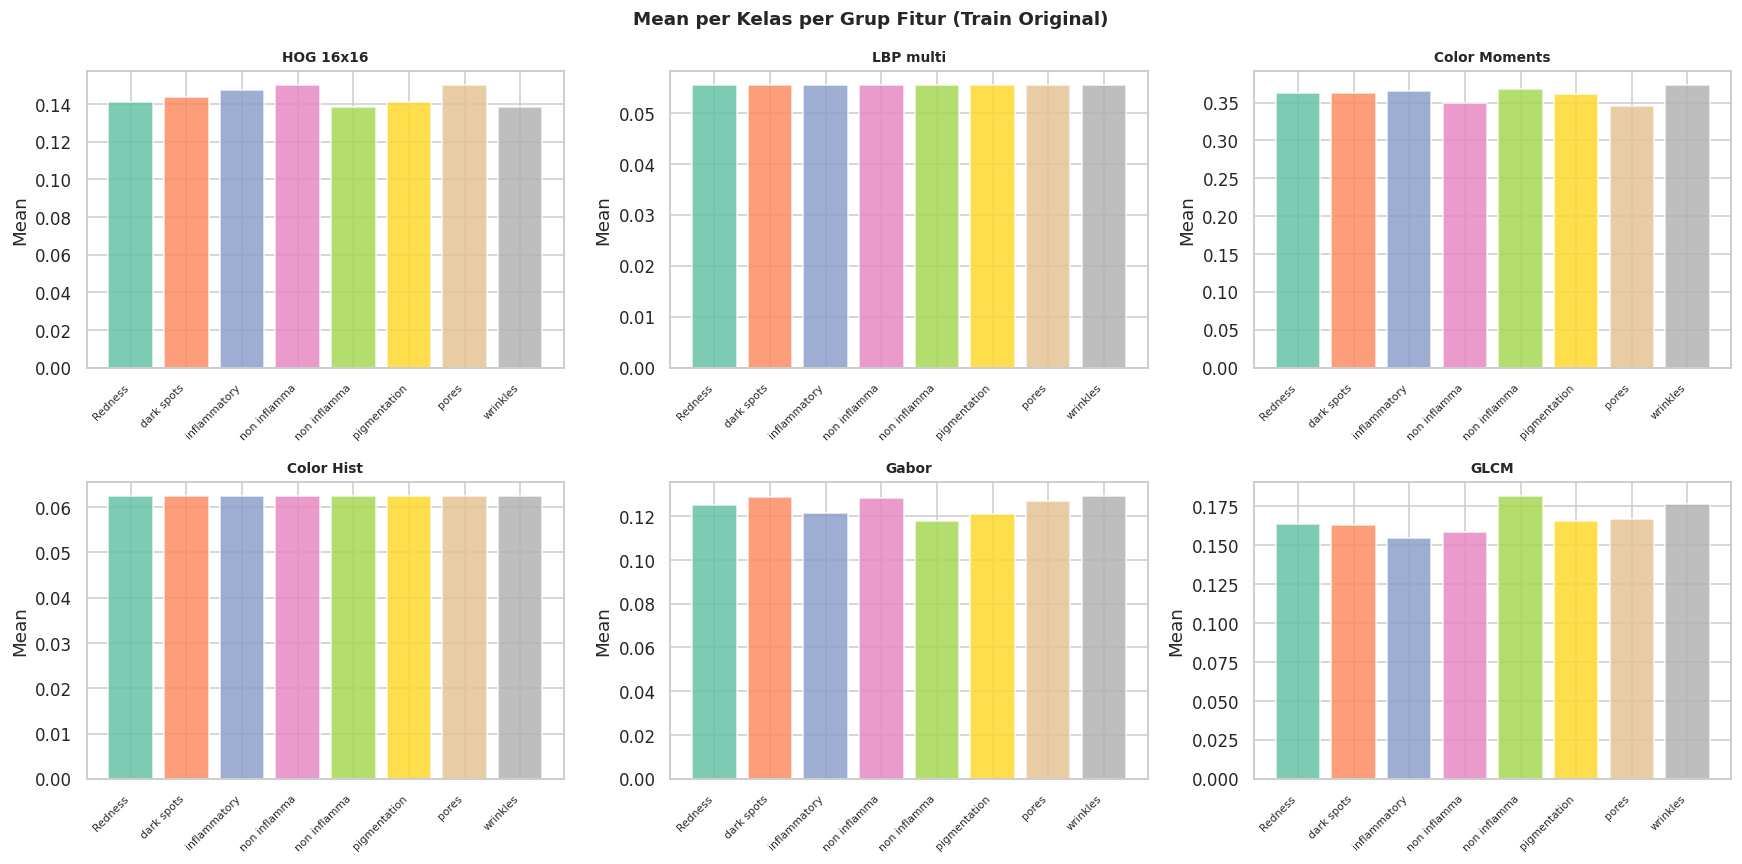

EDA disimpan.


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Mean per Kelas per Grup Fitur (Train Original)',
             fontsize=12, fontweight='bold')
colors = sns.color_palette('Set2', NUM_CLASSES)
short  = [c[:12] for c in le.classes_]

for ax, (gname, (s, e)) in zip(axes.flat, feat_groups.items()):
    gdata  = X_train_orig[:, s:e]
    cmeans = [gdata[y_train_orig == c].mean() for c in range(NUM_CLASSES)]
    ax.bar(range(NUM_CLASSES), cmeans, color=colors, alpha=0.85)
    ax.set_title(gname, fontsize=9, fontweight='bold')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Mean')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_v8.png', bbox_inches='tight')
plt.show()
print('EDA disimpan.')

In [12]:
# ============================================================
# CELL 8: Scaling → PCA → Feature Selection
# FIT hanya pada X_train (termasuk augmented),
# TRANSFORM pada X_test secara terpisah.
# Ini memastikan tidak ada leakage dari test ke pipeline.
# ============================================================
artifacts = {}

print('Step 1: StandardScaler...')
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit+transform train
X_test_sc  = scaler.transform(X_test)        # transform only test
artifacts['scaler'] = scaler
print(f'   shape train={X_train_sc.shape}')

print()
print('Step 2: PCA 95% variance...')
pca         = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)  # fit+transform train
X_test_pca  = pca.transform(X_test_sc)        # transform only test
artifacts['pca'] = pca
print(f'   {X_train_sc.shape[1]} -> {X_train_pca.shape[1]} dim | '
      f'var={pca.explained_variance_ratio_.sum()*100:.1f}%')

print()
print('Step 3: SelectKBest (MI, top 80%)...')
print('   (~2-3 menit...)')
k_features  = int(X_train_pca.shape[1] * 0.80)
selector    = SelectKBest(mutual_info_classif, k=k_features)
X_train_sel = selector.fit_transform(X_train_pca, y_train)  # fit+transform train
X_test_sel  = selector.transform(X_test_pca)                 # transform only test
artifacts['selector'] = selector
artifacts['le']       = le

print(f'   {X_train_pca.shape[1]} -> {X_train_sel.shape[1]} fitur (top 80%)')
print(f'\nShape masuk model: train={X_train_sel.shape}, test={X_test_sel.shape}')

with open(OUTPUT_DIR / 'artifacts_v8.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
with open(OUTPUT_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('Artifacts tersimpan.')

Step 1: StandardScaler...
   shape train=(6293, 2013)

Step 2: PCA 95% variance...
   2013 -> 431 dim | var=95.0%

Step 3: SelectKBest (MI, top 80%)...
   (~2-3 menit...)
   431 -> 344 fitur (top 80%)

Shape masuk model: train=(6293, 344), test=(847, 344)
Artifacts tersimpan.


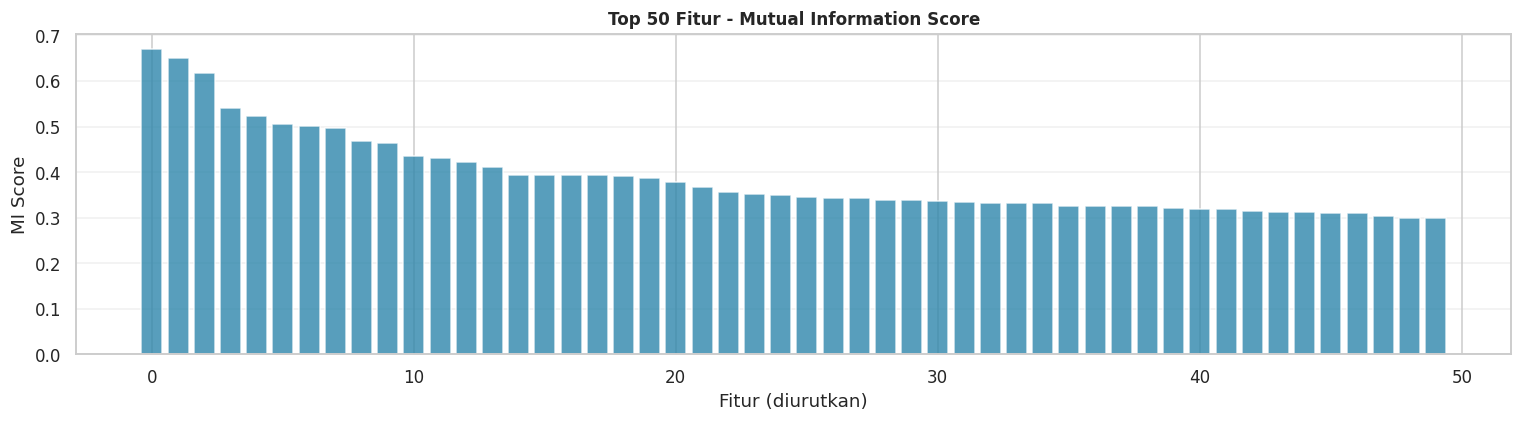

MI: max=0.6701  mean=0.2056


In [13]:
# MI score visualisasi
mi_scores = selector.scores_
n_show    = min(50, len(mi_scores))
top_idx   = np.argsort(mi_scores)[::-1][:n_show]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(n_show), mi_scores[top_idx], color='#2E86AB', alpha=0.8)
ax.set_title(f'Top {n_show} Fitur - Mutual Information Score',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Fitur (diurutkan)')
ax.set_ylabel('MI Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mi_scores_v8.png', bbox_inches='tight')
plt.show()
print(f'MI: max={mi_scores.max():.4f}  mean={mi_scores.mean():.4f}')

In [14]:
# ============================================================
# CELL 9: Baseline Models
# ============================================================
baseline_models = {
    'SVM (RBF)': SVC(
        kernel='rbf', probability=False,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Naive Bayes': GaussianNB(var_smoothing=1e-9),
    'Decision Tree': DecisionTreeClassifier(
        criterion='gini', class_weight='balanced',
        random_state=RANDOM_STATE
    ),
}
baseline_results = {}

print('Baseline training...')
print('=' * 62)
for name, model in baseline_models.items():
    t0     = time.time()
    model.fit(X_train_sel, y_train)
    tr_t   = time.time() - t0
    y_pred = model.predict(X_test_sel)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    baseline_results[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy': acc, 'f1_weighted': f1
    }
    print(f'  [{name:<18}]  Acc={acc:.4f}  F1={f1:.4f}  Train={tr_t:.1f}s')
print('=' * 62)

Baseline training...
  [SVM (RBF)         ]  Acc=0.6647  F1=0.6677  Train=4.2s
  [Naive Bayes       ]  Acc=0.4179  F1=0.4044  Train=0.0s
  [Decision Tree     ]  Acc=0.4026  F1=0.4043  Train=3.4s


In [15]:
# ============================================================
# CELL 10: Tuning SVM
# C kecil (1-10) = margin lebar = general.
# gamma scale = otomatis sesuai fitur.
# class_weight balanced = kompensasi imbalance.
# ============================================================
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tuned_models = {}

print('[1/3] Tuning SVM (RBF)...')
svm_search = RandomizedSearchCV(
    SVC(kernel='rbf', probability=True,
        class_weight='balanced', random_state=RANDOM_STATE),
    param_distributions={
        'C'    : [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50],
        'gamma': ['scale', 0.0005, 0.001, 0.005, 0.01, 0.05],
    },
    n_iter=25,
    cv=cv5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
t0 = time.time()
svm_search.fit(X_train_sel, y_train)
print(f'   Selesai {time.time()-t0:.1f}s | '
      f'Best: {svm_search.best_params_} | '
      f'CV F1={svm_search.best_score_:.4f}')
tuned_models['SVM (RBF)'] = svm_search.best_estimator_

tr_acc = accuracy_score(y_train,
    svm_search.best_estimator_.predict(X_train_sel))
te_acc = accuracy_score(y_test,
    svm_search.best_estimator_.predict(X_test_sel))
gap    = tr_acc - te_acc
print(f'   Train={tr_acc:.4f}  Test={te_acc:.4f}  Gap={gap:.4f}', end=' ')
print('OVERFIT' if gap > 0.15 else 'Slight' if gap > 0.05 else 'OK')

[1/3] Tuning SVM (RBF)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
   Selesai 1387.8s | Best: {'gamma': 'scale', 'C': 30} | CV F1=0.8712
   Train=0.9987  Test=0.6848  Gap=0.3140 OVERFIT


In [16]:
print('[2/3] Tuning Naive Bayes...')
nb_search = GridSearchCV(
    GaussianNB(),
    param_grid={'var_smoothing': np.logspace(-12, -1, 24)},
    cv=cv5, scoring='f1_weighted', n_jobs=-1
)
t0 = time.time()
nb_search.fit(X_train_sel, y_train)
print(f'   Selesai {time.time()-t0:.1f}s | '
      f'Best: {nb_search.best_params_} | '
      f'CV F1={nb_search.best_score_:.4f}')
tuned_models['Naive Bayes'] = nb_search.best_estimator_

[2/3] Tuning Naive Bayes...
   Selesai 1.1s | Best: {'var_smoothing': np.float64(1.492495545051829e-05)} | CV F1=0.4838


In [17]:
print('[3/3] Tuning Decision Tree...')
dt_search = GridSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    param_grid={
        'max_depth'        : [10, 20, 30, 50, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'criterion'        : ['gini', 'entropy'],
        'max_features'     : ['sqrt', 'log2', None],
    },
    cv=cv5, scoring='f1_weighted', n_jobs=-1
)
t0 = time.time()
dt_search.fit(X_train_sel, y_train)
print(f'   Selesai {time.time()-t0:.1f}s | '
      f'Best: {dt_search.best_params_} | '
      f'CV F1={dt_search.best_score_:.4f}')
tuned_models['Decision Tree'] = dt_search.best_estimator_
print('Tuning selesai.')

[3/3] Tuning Decision Tree...
   Selesai 637.6s | Best: {'criterion': 'gini', 'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2} | CV F1=0.7595
Tuning selesai.


In [18]:
# ============================================================
# CELL 11: Evaluasi + Overfitting Report
# ============================================================
def evaluate(name, model, X_t, y_t):
    y_pred = model.predict(X_t)
    return {
        'Model'        : name,
        'Accuracy'     : accuracy_score(y_t, y_pred),
        'Precision'    : precision_score(y_t, y_pred,
                          average='weighted', zero_division=0),
        'Recall'       : recall_score(y_t, y_pred,
                          average='weighted', zero_division=0),
        'F1 (weighted)': f1_score(y_t, y_pred,
                          average='weighted', zero_division=0),
        'y_pred'       : y_pred,
        'model_obj'    : model,
    }

all_eval = {}
for name, info in baseline_results.items():
    r = evaluate(f'{name} (Baseline)', info['model'], X_test_sel, y_test)
    all_eval[r['Model']] = r
for name, model in tuned_models.items():
    r = evaluate(f'{name} (Tuned)', model, X_test_sel, y_test)
    all_eval[r['Model']] = r

df_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 (weighted)']
eval_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k in df_cols}
     for r in all_eval.values()]
).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)

print('=' * 88)
print('HASIL EVALUASI v8')
print('=' * 88)
print(eval_df.to_string(index=False, float_format='{:.4f}'.format))

print()
print('--- Overfitting Report ---')
print(f'   {"Model":<35} {"Train":>8} {"Test":>8} {"Gap":>7}  Status')
print('   ' + '-'*65)
for name, model in (list(baseline_models.items()) +
                    list(tuned_models.items())):
    tr_a = accuracy_score(y_train, model.predict(X_train_sel))
    te_a = accuracy_score(y_test,  model.predict(X_test_sel))
    g    = tr_a - te_a
    st   = ('OVERFIT' if g > 0.15
            else 'Slight' if g > 0.05
            else 'OK')
    print(f'   {name:<35} {tr_a:>8.4f} {te_a:>8.4f} {g:>7.4f}  {st}')

HASIL EVALUASI v8
                   Model  Accuracy  Precision  Recall  F1 (weighted)
       SVM (RBF) (Tuned)    0.6848     0.6941  0.6848         0.6866
    SVM (RBF) (Baseline)    0.6647     0.6748  0.6647         0.6677
  Naive Bayes (Baseline)    0.4179     0.4567  0.4179         0.4044
Decision Tree (Baseline)    0.4026     0.4078  0.4026         0.4043
   Decision Tree (Tuned)    0.4026     0.4078  0.4026         0.4043
     Naive Bayes (Tuned)    0.4168     0.4557  0.4168         0.4036

--- Overfitting Report ---
   Model                                  Train     Test     Gap  Status
   -----------------------------------------------------------------
   SVM (RBF)                             0.9674   0.6647  0.3027  OVERFIT
   Naive Bayes                           0.5231   0.4179  0.1052  Slight
   Decision Tree                         1.0000   0.4026  0.5974  OVERFIT
   SVM (RBF)                             0.9987   0.6848  0.3140  OVERFIT
   Naive Bayes                    

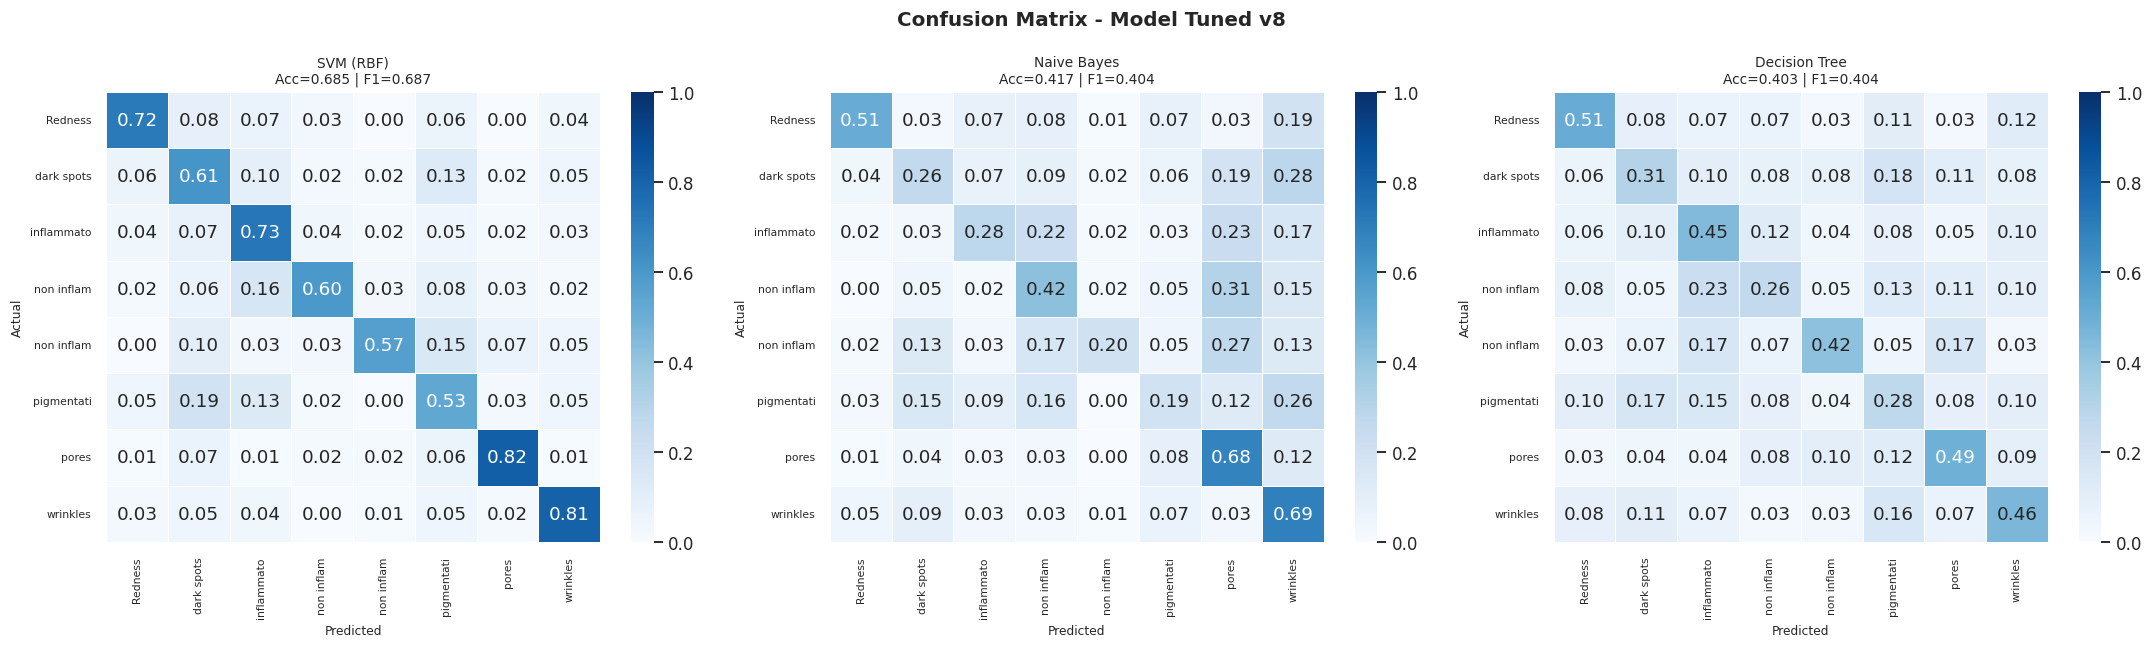

In [19]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix - Model Tuned v8',
             fontsize=13, fontweight='bold')
short = [c[:10] for c in le.classes_]

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_sel)
    cm_n   = confusion_matrix(y_test, y_pred).astype(float)
    cm_n  /= cm_n.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2f', ax=ax,
                xticklabels=short, yticklabels=short,
                cmap='Blues', vmin=0, vmax=1, linewidths=0.5)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    ax.set_title(f'{name}\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual',    fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_v8.png', bbox_inches='tight')
plt.show()

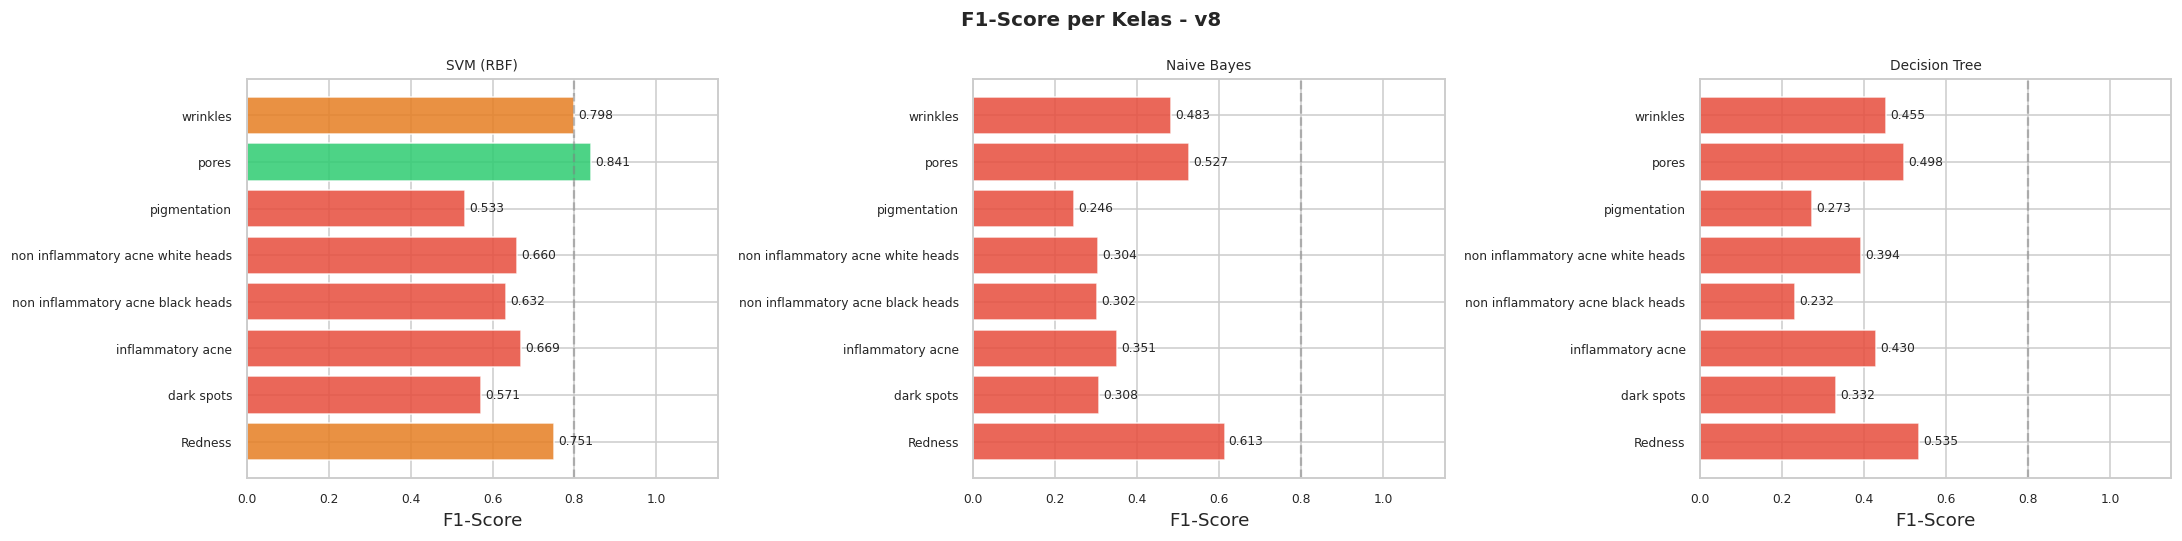

In [20]:
# F1 per kelas
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('F1-Score per Kelas - v8', fontsize=13, fontweight='bold')
for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_sel)
    f1_per = f1_score(y_test, y_pred, average=None, zero_division=0)
    bc = ['#E74C3C' if f < 0.70
          else '#E67E22' if f < 0.80
          else '#2ECC71' for f in f1_per]
    ax.barh(le.classes_, f1_per, color=bc, alpha=0.85, edgecolor='white')
    ax.axvline(0.80, linestyle='--', color='gray', alpha=0.5)
    for i, v in enumerate(f1_per):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
    ax.set_xlabel('F1-Score')
    ax.set_title(name, fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'f1_per_class_v8.png', bbox_inches='tight')
plt.show()

In [21]:
# ============================================================
# CELL 12: Ranking & Best Model
# ============================================================
ranking_df = eval_df.sort_values(
    'F1 (weighted)', ascending=False
).reset_index(drop=True)

print('RANKING:')
print('=' * 88)
for i, row in ranking_df.iterrows():
    medal = ['1st', '2nd', '3rd'][i] if i < 3 else f' {i+1}th'
    print(f'   {medal}  [{row["Model"]:<42}]  '
          f'Acc={row["Accuracy"]:.4f}  F1={row["F1 (weighted)"]:.4f}')
print('=' * 88)

best_name      = ranking_df.iloc[0]['Model']
best_acc       = ranking_df.iloc[0]['Accuracy']
best_f1        = ranking_df.iloc[0]['F1 (weighted)']
best_model_obj = all_eval[best_name]['model_obj']
y_pred_best    = all_eval[best_name]['y_pred']

print(f'\nBest: {best_name}')
print(f'   Accuracy : {best_acc*100:.2f}%')
print(f'   F1       : {best_f1:.4f}')
print()
print(classification_report(
    y_test, y_pred_best,
    target_names=le.classes_, digits=4, zero_division=0
))

RANKING:
   1st  [SVM (RBF) (Tuned)                         ]  Acc=0.6848  F1=0.6866
   2nd  [SVM (RBF) (Baseline)                      ]  Acc=0.6647  F1=0.6677
   3rd  [Naive Bayes (Baseline)                    ]  Acc=0.4179  F1=0.4044
    4th  [Decision Tree (Baseline)                  ]  Acc=0.4026  F1=0.4043
    5th  [Decision Tree (Tuned)                     ]  Acc=0.4026  F1=0.4043
    6th  [Naive Bayes (Tuned)                       ]  Acc=0.4168  F1=0.4036

Best: SVM (RBF) (Tuned)
   Accuracy : 68.48%
   F1       : 0.6866

                                   precision    recall  f1-score   support

                          Redness     0.7890    0.7167    0.7511       120
                       dark spots     0.5352    0.6129    0.5714       124
                inflammatory acne     0.6197    0.7273    0.6692       121
non inflammatory acne black heads     0.6727    0.5968    0.6325        62
non inflammatory acne white heads     0.7907    0.5667    0.6602        60
             

In [22]:
# ============================================================
# CELL 13: Simpan Artefak
# ============================================================
with open(OUTPUT_DIR / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

meta = {
    'version'            : 'v8',
    'best_model_name'    : best_name,
    'accuracy'           : float(best_acc),
    'f1_weighted'        : float(best_f1),
    'img_size'           : list(IMG_SIZE),
    'haar_cascade'       : 'dipakai di load_and_preprocess, fallback aman jika tidak terdeteksi',
    'key_fix_v8'         : 'fitur diekstrak dari original dulu, BARU split & augmentasi di feature space',
    'augmentation'       : 'gaussian noise 1pct pada fitur kelas minoritas (bukan augmentasi image)',
    'feature_pipeline'   : 'HOG16 + LBP(R=1,2,3) + ColorMoments(RGB+HSV+LAB) + ColorHist16bin + Gabor + GLCM',
    'pca_variance'       : '95pct',
    'kbest_pct'          : '80pct',
    'feature_dim_raw'    : int(X_all.shape[1]),
    'feature_dim_pca'    : int(X_train_pca.shape[1]),
    'feature_dim_final'  : int(X_train_sel.shape[1]),
    'classes'            : list(le.classes_),
    'inference_order'    : [
        '1. load image RGB uint8',
        '2. crop_face_roi()  # Haar Cascade + fallback aman',
        '3. resize 128x128, normalize 0-1',
        '4. extract_features() shape (2013,)',
        '5. artifacts[scaler].transform([[feats]])',
        '6. artifacts[pca].transform()',
        '7. artifacts[selector].transform()',
        '8. best_model.predict()',
        '9. le.inverse_transform()',
    ]
}
with open(OUTPUT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Artefak tersimpan:')
for fname in ['best_model.pkl', 'artifacts_v8.pkl',
              'label_encoder.pkl', 'model_metadata.json']:
    p = OUTPUT_DIR / fname
    if p.exists():
        print(f'   {fname:<35} ({p.stat().st_size/1024:.1f} KB)')

Artefak tersimpan:
   best_model.pkl                      (12227.9 KB)
   artifacts_v8.pkl                    (3455.0 KB)
   label_encoder.pkl                   (1.3 KB)
   model_metadata.json                 (1.3 KB)
